In [1]:
import random
import math
from crossover import *
from fitness import *
from initializers import *
from mutation import *
from operations import *
from population import *
from program import *
from selection import *

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

def plot_evolution(population, generation_count, stop_at_fitness):
    (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = population.evolve(generation_count, stop_at_fitness)
    fig, ax = plt.subplots()
    ax.set_title(F"Best Fitness")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.plot(generations, mins)
    plt.show()
    all_time_best_program.print_readable_code()
    return (generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats)

def plot_1d_solution(x_test, y_test, program):
    y_hats = [program.execute(x)[0] for x in x_test]
    fig, ax = plt.subplots()
    ax.plot(x_test, y_test, label="Actual")
    ax.plot(x_test, y_hats, label="Predicted")
    ax.legend()
    plt.show()


In [ ]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm]
x_train = np.linspace(-10, 10, 100).tolist()
y_train = [0.3 * x**2 for x in x_train]

x_gd_train = np.linspace(-10, 10, 25).tolist()
y_gd_train = [0.3 * x**2 for x in x_gd_train]

fitness_func = mse_fitness_tensor(x_train, y_train)
custom_mutation_func = combined_mutation(
    standard_mutation(operations, 0.3, 0.1),
    # gradient_descent_mutation(1.0, 0.01, 2, fitness_func)
)

In [3]:
operations = [Addition, Subtraction, Multiplication, Division, Square, SquareRoot, Exponent, Logarithm, Sine]
x_train = np.linspace(0.0, 2.0 * np.pi, 100)
y_train = np.cos(x_train)

x_train = x_train.tolist()
y_train = y_train.tolist()

x_gd_train = np.linspace(0.0, 2.0 * np.pi, 25)
y_gd_train = np.cos(x_gd_train)

x_gd_train = x_gd_train.tolist()
y_gd_train = y_gd_train.tolist()

fitness_func = mse_fitness_tensor(x_train, y_train)
custom_mutation_func = combined_mutation(
    standard_mutation(operations, 0.3, 0.0),
    gradient_descent_mutation(0.25, 0.01, 2, fitness_func)
)

Beginning evolution.
Completed 0/50 generations. Best Fitness: inf					

c:\Users\Patri\source\repos\LGP\fitness.py:16: RuntimeWarning: overflow encountered in square
  error += (y - y_hat) ** 2
c:\Users\Patri\source\repos\LGP\mutation.py:60: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten\src\ATen/core/TensorBody.h:494.)
  new_program.initial_values[i] = r - learning_rate * (r.grad if r.grad != None and not math.isnan(r.grad.item()) else 0.0)


Completed 5/50 generations. Best Fitness: 65375.56427165484						

c:\Users\Patri\source\repos\LGP\fitness.py:16: RuntimeWarning: overflow encountered in add
  error += (y - y_hat) ** 2


Completed 50/50 generations. Best Fitness: 82.01728154603872						
Evolution complete.


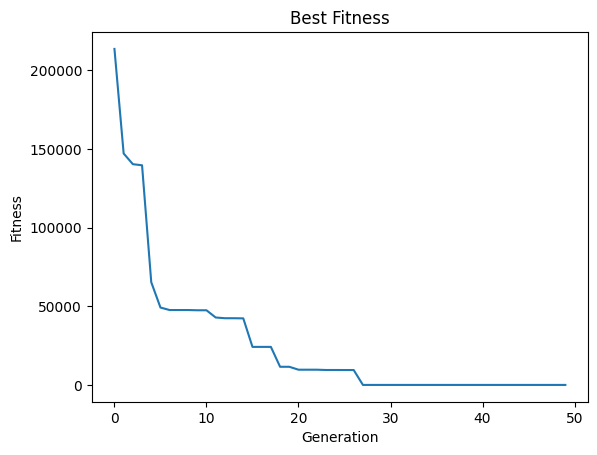

# Register Initialization
r0 = 1.0
r1 = 1.0
r2 = 1.0
r3 = 82334.6640625
# Start of Program
 1.  r2 = ln(|r-1|)
 2.  r2 = (|r-1|+epsilon) ** r-1
 3.  r0 = sin(r1)
 4.  r1 = r-1 / r0
 5.  r0 = sqrt(|r0|)
 6.  r0 = r1 + r3
 7.  r2 = r-1 * r1
 8.  r2 = r2 + r2
 9.  r0 = r2 * r-1
10.  r1 = (|r1|+epsilon) ** r2
# End of Program


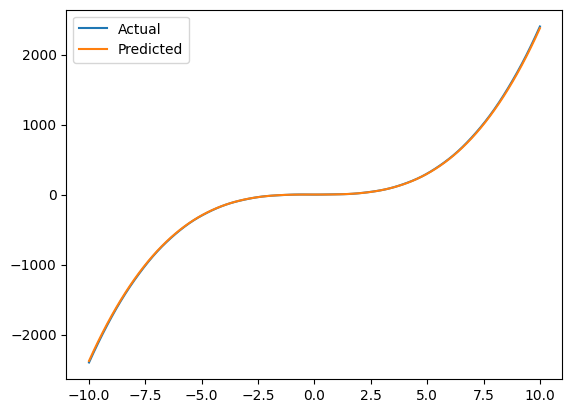

In [9]:
fitness_func = mse_fitness(x_train, y_train)
selection_func = binary_tournament_selection
program_mutation_rate = 1.0
crossover_rate = 0.5
instruction_count = 10
register_count = 4
input_value_count = 1
output_value_count = 1
register_initializer = RI_always_one
# crossover_func = standard_crossover_1pt()
crossover_func=standard_crossover_2pt()
survival_selection_func = binary_tournament_selection
lam = 1000
nu = 500
mu = 1000

pop = Population(lam, nu, mu, selection_func, custom_mutation_func, program_mutation_rate, \
    crossover_rate, instruction_count, register_count, input_value_count, output_value_count, \
    operations, register_initializer, fitness_func, crossover_func, survival_selection_func, mu_plus_lambda=True)

(generations, means, mins, all_time_best_fitness, all_time_best_program, all_custom_stats) = plot_evolution(pop, 50, 0.0001)
plot_1d_solution(x_train, y_train, all_time_best_program)